# 01 — Environment Inspection corrigé

Ce notebook inspecte proprement l’environnement du **RL Sailing Challenge**.

Corrections intégrées :
- détection robuste du dépôt ;
- import conforme à l’architecture réelle : `from src.env_sailing import SailingEnv` ;
- création correcte de l’environnement : `SailingEnv(**get_wind_scenario(name))` ;
- utilisation correcte de `env.world_map` et `env.wind_field` ;
- import correct de `calculate_sailing_efficiency` ;
- suppression des f-strings / strings cassées ;
- aucune dépendance à `env.clone()`, qui n’existe pas dans le dépôt.


## 1. Imports, dépendances et détection du dépôt

Lance ce notebook depuis :
- la racine du dépôt ; ou
- le dossier `notebooks/`.

Si l’import de `gymnasium` échoue, exécute dans un terminal depuis la racine du dépôt :

```bash
pip install -r requirements.txt
```


In [1]:

from pathlib import Path
import os
import sys
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optionnel : renseigne manuellement le chemin du dépôt si la détection automatique échoue.
# Exemple Windows :
# MANUAL_REPO_ROOT = r"C:\\Users\\...\\stable_v2_RL_sailing_challenge"
MANUAL_REPO_ROOT = None


def safe_cwd():
    # Return a valid current working directory, even if the kernel cwd was deleted.
    try:
        return Path.cwd().resolve()
    except FileNotFoundError:
        return Path.home().resolve()


def find_repo_root(manual_root=None):
    candidates = []

    if manual_root:
        candidates.append(Path(manual_root).expanduser().resolve())

    cwd = safe_cwd()
    candidates.extend([cwd] + list(cwd.parents))

    # Common fallback locations, harmless if they do not exist.
    candidates.extend([
        Path("/mnt/data/stable_v2_RL_sailing_challenge"),
        Path("/mnt/data/sailing_repo/stable_v2_RL_sailing_challenge"),
        Path("/mnt/data/sailing/stable_v2_RL_sailing_challenge"),
        Path.home() / "stable_v2_RL_sailing_challenge",
    ])

    seen = set()
    for p in candidates:
        if p in seen:
            continue
        seen.add(p)
        if (p / "src" / "env_sailing.py").exists():
            return p

    raise FileNotFoundError(
        "Impossible de trouver le dépôt. "
        "Place ce notebook dans le dépôt ou renseigne MANUAL_REPO_ROOT."
    )


REPO_ROOT = find_repo_root(MANUAL_REPO_ROOT)
SRC_DIR = REPO_ROOT / "src"

# env_sailing.py importe des modules en `src.*`, donc il faut mettre la racine du repo dans sys.path.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT =", REPO_ROOT)
print("SRC_DIR   =", SRC_DIR)

# Vérification simple des dépendances.
missing = []
for pkg in ["gymnasium", "scipy", "numpy", "matplotlib"]:
    if importlib.util.find_spec(pkg) is None:
        missing.append(pkg)

if missing:
    print("Packages manquants :", missing)
    print("Depuis la racine du dépôt, exécute : pip install -r requirements.txt")
else:
    print("Dépendances principales OK.")


REPO_ROOT = /home/onyxia/work/stable_v2_RL_sailing_challenge
SRC_DIR   = /home/onyxia/work/stable_v2_RL_sailing_challenge/src
Dépendances principales OK.


In [2]:

from src.env_sailing import SailingEnv
from src.wind_scenarios import get_wind_scenario, WIND_SCENARIOS
from src.sailing_physics import calculate_sailing_efficiency

print("Imports OK.")
print("Scénarios disponibles :", list(WIND_SCENARIOS.keys()))


Imports OK.
Scénarios disponibles : ['training_1', 'training_2', 'training_3']


## 2. Création correcte de l’environnement

Dans le dépôt réel, `get_wind_scenario(name)` renvoie un dictionnaire de paramètres :

```python
{
    "wind_init_params": ...,
    "wind_evol_params": ...
}
```

Donc la création correcte est :

```python
env = SailingEnv(**get_wind_scenario(name))
```


In [3]:

scenario_name = "training_1"
scenario_params = get_wind_scenario(scenario_name)

# static_wind=True facilite l'inspection visuelle ; pour l'évaluation, le vent évolue par défaut.
env = SailingEnv(
    **scenario_params,
    static_wind=True,
    render_mode="rgb_array",
    show_full_trajectory=True,
)

obs, info = env.reset(seed=0)

print("Scenario:", scenario_name)
print("Grid size:", env.grid_size)
print("Action space:", env.action_space)
print("Observation space shape:", env.observation_space.shape)
print("Observation shape:", obs.shape)
print("Start position:", env.position)
print("Goal position:", env.goal_position)
print("Initial velocity:", env.velocity)
print("Initial local wind:", info["wind"])
print("World map shape:", env.world_map.shape)
print("Wind field shape:", env.wind_field.shape)


Scenario: training_1
Grid size: (128, 128)
Action space: Discrete(9)
Observation space shape: (49158,)
Observation shape: (49158,)
Start position: [64  0]
Goal position: [ 64 127]
Initial velocity: [0. 0.]
Initial local wind: [-5.45541148  8.38084039]
World map shape: (128, 128)
Wind field shape: (128, 128, 2)


## 3. Parser correctement l’observation

L’observation réelle vaut :

```text
[x, y, vx, vy, wx, wy, flattened wind field, flattened world map]
```


In [4]:

def parse_observation(observation, grid_size=(128, 128)):
    # Parse the flat observation returned by SailingEnv.
    W, H = grid_size
    observation = np.asarray(observation, dtype=np.float32)

    n_wind = W * H * 2
    n_world = W * H
    expected_len = 6 + n_wind + n_world

    if observation.shape[0] != expected_len:
        raise ValueError(
            f"Unexpected observation length: {observation.shape[0]} != {expected_len}"
        )

    position = observation[0:2].astype(np.float32)
    velocity = observation[2:4].astype(np.float32)
    local_wind = observation[4:6].astype(np.float32)

    wind_field = observation[6:6+n_wind].reshape(H, W, 2)
    world_map = observation[6+n_wind:6+n_wind+n_world].reshape(H, W)

    return {
        "position": position,
        "velocity": velocity,
        "local_wind": local_wind,
        "wind_field": wind_field,
        "world_map": world_map,
    }


parsed = parse_observation(obs, env.grid_size)

for key, value in parsed.items():
    print(f"{key:12s} shape={np.shape(value)} dtype={getattr(value, 'dtype', type(value))}")

print("\nPosition from obs:", parsed["position"])
print("Velocity from obs:", parsed["velocity"])
print("Local wind from obs:", parsed["local_wind"])
print("Matches env.world_map:", np.allclose(parsed["world_map"], env.world_map))
print("Matches env.wind_field:", np.allclose(parsed["wind_field"], env.wind_field))


position     shape=(2,) dtype=float32
velocity     shape=(2,) dtype=float32
local_wind   shape=(2,) dtype=float32
wind_field   shape=(128, 128, 2) dtype=float32
world_map    shape=(128, 128) dtype=float32

Position from obs: [64.  0.]
Velocity from obs: [0. 0.]
Local wind from obs: [-5.4554114  8.38084  ]
Matches env.world_map: True
Matches env.wind_field: True


## 4. Référence des actions

In [5]:

ACTION_NAMES = {
    0: "North",
    1: "North-East",
    2: "East",
    3: "South-East",
    4: "South",
    5: "South-West",
    6: "West",
    7: "North-West",
    8: "Stay",
}

rows = []
for action in range(9):
    direction = env._action_to_direction(action)
    rows.append({
        "action": action,
        "name": ACTION_NAMES[action],
        "dx": int(direction[0]),
        "dy": int(direction[1]),
    })

actions_df = pd.DataFrame(rows)
display(actions_df)


,action,name,dx,dy
0,0,North,0,1
1,1,North-East,1,1
2,2,East,1,0
3,3,South-East,1,-1
4,4,South,0,-1
5,5,South-West,-1,-1
6,6,West,-1,0
7,7,North-West,-1,1
8,8,Stay,0,0


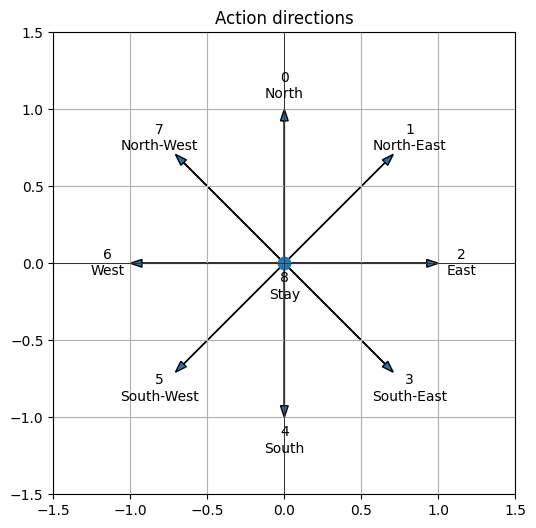

In [6]:

fig, ax = plt.subplots(figsize=(6, 6))
origin = np.array([0.0, 0.0])

for action in range(9):
    d = env._action_to_direction(action).astype(float)

    if np.linalg.norm(d) > 0:
        d = d / np.linalg.norm(d)
        ax.arrow(
            origin[0], origin[1],
            d[0], d[1],
            head_width=0.05,
            length_includes_head=True,
        )
        ax.text(
            1.15 * d[0],
            1.15 * d[1],
            f"{action}\n{ACTION_NAMES[action]}",
            ha="center",
            va="center",
        )
    else:
        ax.scatter([0], [0], s=80)
        ax.text(
            0,
            -0.15,
            f"{action}\n{ACTION_NAMES[action]}",
            ha="center",
            va="center",
        )

ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect("equal")
ax.grid(True)
ax.set_title("Action directions")
plt.show()


## 5. Inspection de la carte et de l’île

Island cells: 2955
Island x-range: 38 90
Island y-range: 17 85
Start: (np.int64(64), np.int64(0))
Goal: (np.int64(64), np.int64(127))


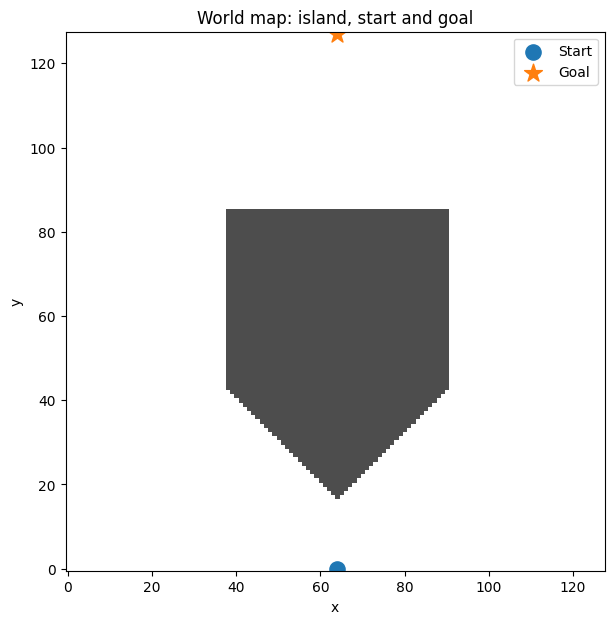

In [7]:

world = env.world_map
ys, xs = np.where(world == 1)

print("Island cells:", len(xs))
print("Island x-range:", int(xs.min()), int(xs.max()))
print("Island y-range:", int(ys.min()), int(ys.max()))
print("Start:", tuple(env.position))
print("Goal:", tuple(env.goal_position))

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(world, origin="lower", cmap="Greys", alpha=0.7)
ax.scatter([env.position[0]], [env.position[1]], s=120, label="Start", marker="o")
ax.scatter([env.goal_position[0]], [env.goal_position[1]], s=180, label="Goal", marker="*")
ax.set_title("World map: island, start and goal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()


## 6. Visualisation des scénarios de vent

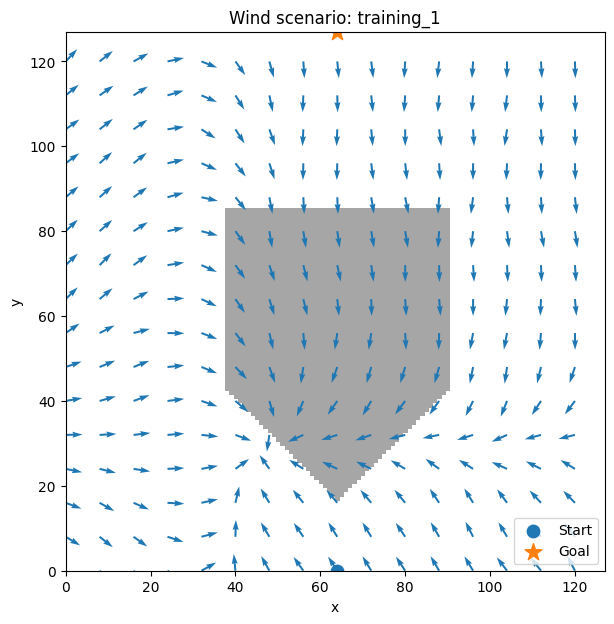

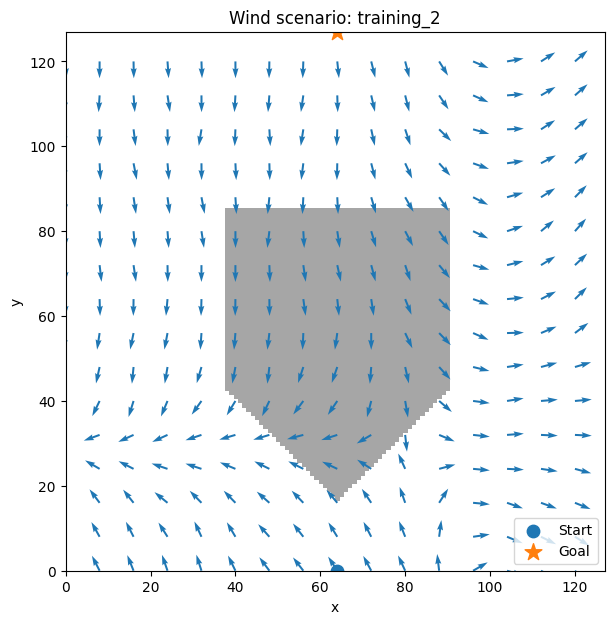

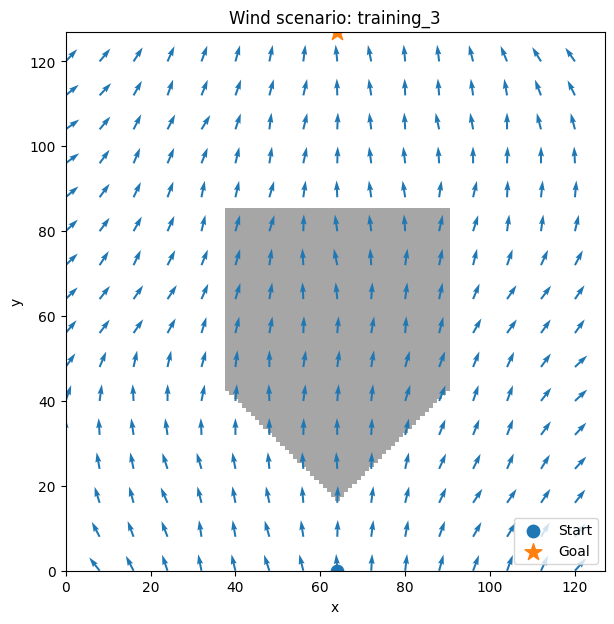

In [8]:

def plot_wind_scenario(name, seed=0, density=8, static_wind=True):
    e = SailingEnv(
        **get_wind_scenario(name),
        static_wind=static_wind,
        render_mode="rgb_array",
    )
    e.reset(seed=seed)

    wind = e.wind_field
    world = e.world_map
    W, H = e.grid_size

    xs = np.arange(0, W, density)
    ys = np.arange(0, H, density)
    X, Y = np.meshgrid(xs, ys)

    U = wind[Y, X, 0]
    V = wind[Y, X, 1]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(world, origin="lower", cmap="Greys", alpha=0.35)
    ax.quiver(X, Y, U, V, color="tab:blue", scale=320)
    ax.scatter([e.position[0]], [e.position[1]], s=80, marker="o", label="Start")
    ax.scatter([e.goal_position[0]], [e.goal_position[1]], s=160, marker="*", label="Goal")
    ax.set_title(f"Wind scenario: {name}")
    ax.set_xlim(0, W - 1)
    ax.set_ylim(0, H - 1)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="lower right")
    plt.show()


for name in WIND_SCENARIOS.keys():
    plot_wind_scenario(name, seed=0, density=8)


## 7. Effet d’une action au premier pas

On réinitialise l’environnement pour chaque action afin de comparer proprement les effets.


In [9]:

def one_step_action_table(name="training_1", seed=0):
    rows = []

    for action in range(9):
        e = SailingEnv(
            **get_wind_scenario(name),
            static_wind=True,
            render_mode="rgb_array",
        )

        e.reset(seed=seed)

        pos0 = e.position.copy()
        vel0 = e.velocity.copy()
        wind0 = e._get_wind_at_position(pos0).copy()

        obs1, reward, terminated, truncated, info1 = e.step(action)

        pos1 = e.position.copy()
        vel1 = e.velocity.copy()

        rows.append({
            "scenario": name,
            "seed": seed,
            "action": action,
            "name": ACTION_NAMES[action],
            "x0": int(pos0[0]),
            "y0": int(pos0[1]),
            "vx0": float(vel0[0]),
            "vy0": float(vel0[1]),
            "wx0": float(wind0[0]),
            "wy0": float(wind0[1]),
            "x1": int(pos1[0]),
            "y1": int(pos1[1]),
            "vx1": float(vel1[0]),
            "vy1": float(vel1[1]),
            "reward": float(reward),
            "terminated": bool(terminated),
            "truncated": bool(truncated),
            "is_stuck": bool(info1.get("is_stuck", False)),
            "distance_to_goal": float(info1.get("distance_to_goal", np.nan)),
        })

    return pd.DataFrame(rows)


for name in WIND_SCENARIOS.keys():
    print("\n" + "=" * 80)
    print(name)
    display(one_step_action_table(name, seed=0))



training_1


,scenario,seed,action,name,x0,y0,vx0,vy0,wx0,wy0,x1,y1,vx1,vy1,reward,terminated,truncated,is_stuck,distance_to_goal
0,training_1,0,0,North,64,0,0.0,0.0,-5.455411,8.38084,64,2,0.0,2.0,0.0,False,False,False,125.000000
1,training_1,0,1,North-East,64,0,0.0,0.0,-5.455411,8.38084,66,2,2.0,2.0,0.0,False,False,False,125.015999
2,training_1,0,2,East,64,0,0.0,0.0,-5.455411,8.38084,65,0,1.0,0.0,0.0,False,False,False,127.003937
3,training_1,0,3,South-East,64,0,0.0,0.0,-5.455411,8.38084,64,0,0.0,0.0,0.0,False,False,False,127.000000
4,training_1,0,4,South,64,0,0.0,0.0,-5.455411,8.38084,64,0,0.0,0.0,0.0,False,False,False,127.000000
5,training_1,0,5,South-West,64,0,0.0,0.0,-5.455411,8.38084,62,0,-2.0,-2.0,0.0,False,False,False,127.015747
6,training_1,0,6,West,64,0,0.0,0.0,-5.455411,8.38084,62,0,-2.0,0.0,0.0,False,False,False,127.015747
7,training_1,0,7,North-West,64,0,0.0,0.0,-5.455411,8.38084,63,1,-1.0,1.0,0.0,False,False,False,126.003968
8,training_1,0,8,Stay,64,0,0.0,0.0,-5.455411,8.38084,64,0,0.0,0.0,0.0,False,False,False,127.000000



training_2


,scenario,seed,action,name,x0,y0,vx0,vy0,wx0,wy0,x1,y1,vx1,vy1,reward,terminated,truncated,is_stuck,distance_to_goal
0,training_2,0,0,North,64,0,0.0,0.0,-5.436711,8.392984,64,2,0.0,2.0,0.0,False,False,False,125.000000
1,training_2,0,1,North-East,64,0,0.0,0.0,-5.436711,8.392984,66,2,2.0,2.0,0.0,False,False,False,125.015999
2,training_2,0,2,East,64,0,0.0,0.0,-5.436711,8.392984,65,0,1.0,0.0,0.0,False,False,False,127.003937
3,training_2,0,3,South-East,64,0,0.0,0.0,-5.436711,8.392984,64,0,0.0,0.0,0.0,False,False,False,127.000000
4,training_2,0,4,South,64,0,0.0,0.0,-5.436711,8.392984,64,0,0.0,0.0,0.0,False,False,False,127.000000
5,training_2,0,5,South-West,64,0,0.0,0.0,-5.436711,8.392984,62,0,-2.0,-2.0,0.0,False,False,False,127.015747
6,training_2,0,6,West,64,0,0.0,0.0,-5.436711,8.392984,62,0,-2.0,0.0,0.0,False,False,False,127.015747
7,training_2,0,7,North-West,64,0,0.0,0.0,-5.436711,8.392984,63,1,-1.0,1.0,0.0,False,False,False,126.003968
8,training_2,0,8,Stay,64,0,0.0,0.0,-5.436711,8.392984,64,0,0.0,0.0,0.0,False,False,False,127.000000



training_3


,scenario,seed,action,name,x0,y0,vx0,vy0,wx0,wy0,x1,y1,vx1,vy1,reward,terminated,truncated,is_stuck,distance_to_goal
0,training_3,0,0,North,64,0,0.0,0.0,-0.685571,9.976472,64,1,0.0,1.0,0.0,False,False,False,126.000000
1,training_3,0,1,North-East,64,0,0.0,0.0,-0.685571,9.976472,66,2,2.0,2.0,0.0,False,False,False,125.015999
2,training_3,0,2,East,64,0,0.0,0.0,-0.685571,9.976472,66,0,2.0,0.0,0.0,False,False,False,127.015747
3,training_3,0,3,South-East,64,0,0.0,0.0,-0.685571,9.976472,64,0,0.0,0.0,0.0,False,False,False,127.000000
4,training_3,0,4,South,64,0,0.0,0.0,-0.685571,9.976472,64,0,0.0,0.0,0.0,False,False,False,127.000000
5,training_3,0,5,South-West,64,0,0.0,0.0,-0.685571,9.976472,63,0,-1.0,-1.0,0.0,False,False,False,127.003937
6,training_3,0,6,West,64,0,0.0,0.0,-0.685571,9.976472,62,0,-2.0,0.0,0.0,False,False,False,127.015747
7,training_3,0,7,North-West,64,0,0.0,0.0,-0.685571,9.976472,62,2,-2.0,2.0,0.0,False,False,False,125.015999
8,training_3,0,8,Stay,64,0,0.0,0.0,-0.685571,9.976472,64,0,0.0,0.0,0.0,False,False,False,127.000000


## 8. Physique de voile : efficacité selon l’angle au vent

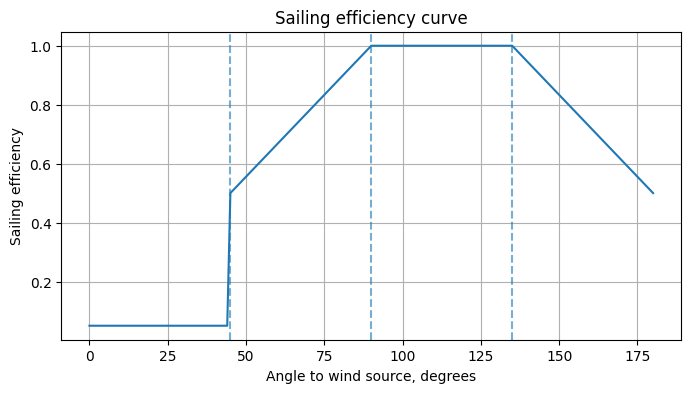

In [10]:

angles = np.linspace(0, np.pi, 181)
wind_direction = np.array([0.0, -1.0])  # wind going downward

effs = []
for angle in angles:
    # angle = 0 : bateau directement face au vent.
    boat_direction = np.array([np.sin(-angle), np.cos(-angle)])
    effs.append(calculate_sailing_efficiency(boat_direction, wind_direction))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(angles), effs)
ax.axvline(45, linestyle="--", alpha=0.6)
ax.axvline(90, linestyle="--", alpha=0.6)
ax.axvline(135, linestyle="--", alpha=0.6)
ax.set_xlabel("Angle to wind source, degrees")
ax.set_ylabel("Sailing efficiency")
ax.set_title("Sailing efficiency curve")
ax.grid(True)
plt.show()


## 9. Rollout simple : politique toujours Nord

Cette cellule sert seulement de baseline de compréhension.


Scenario: training_3
Steps: 10
Reward: 0.0
Terminated: True
Truncated: False
Final position: [64 18]
Is stuck: True


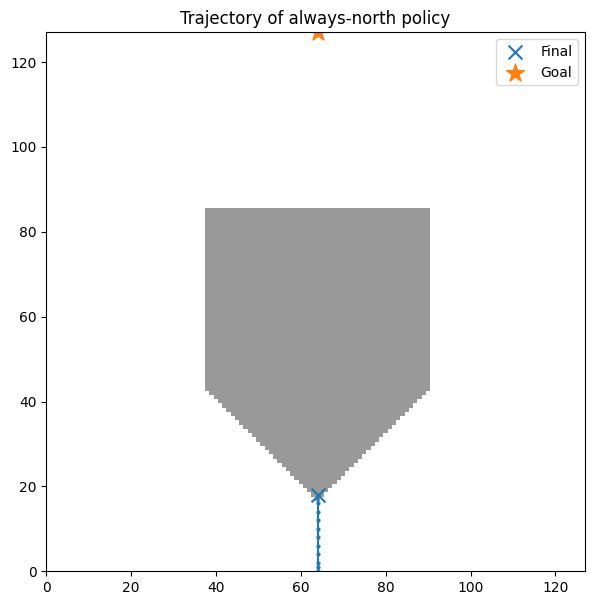

In [11]:

def rollout(env, policy_fn, seed=0, max_steps=500):
    obs, info = env.reset(seed=seed)
    total_reward = 0.0
    trajectory = [env.position.copy()]
    infos = []

    for t in range(max_steps):
        action = int(policy_fn(obs, info, env))
        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        trajectory.append(env.position.copy())
        infos.append({**info, "action": action, "reward": reward})

        if terminated or truncated:
            break

    return np.array(trajectory), total_reward, terminated, truncated, infos


def always_north_policy(obs, info, env):
    return 0


name = "training_3"
e = SailingEnv(
    **get_wind_scenario(name),
    render_mode="rgb_array",
    show_full_trajectory=True,
)

traj, reward, terminated, truncated, infos = rollout(e, always_north_policy, seed=0)

print("Scenario:", name)
print("Steps:", len(traj) - 1)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Final position:", traj[-1])
print("Is stuck:", getattr(e, "is_stuck", None))

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(e.world_map, origin="lower", cmap="Greys", alpha=0.4)
ax.plot(traj[:, 0], traj[:, 1], marker="o", markersize=2, linewidth=1.5)
ax.scatter([e.position[0]], [e.position[1]], s=100, marker="x", label="Final")
ax.scatter([e.goal_position[0]], [e.goal_position[1]], s=180, marker="*", label="Goal")
ax.set_title("Trajectory of always-north policy")
ax.set_xlim(0, 127)
ax.set_ylim(0, 127)
ax.legend()
plt.show()


## 10. Test de rendu RGB

Rendered image shape: (1000, 1000, 3)
Rendered image dtype: uint8


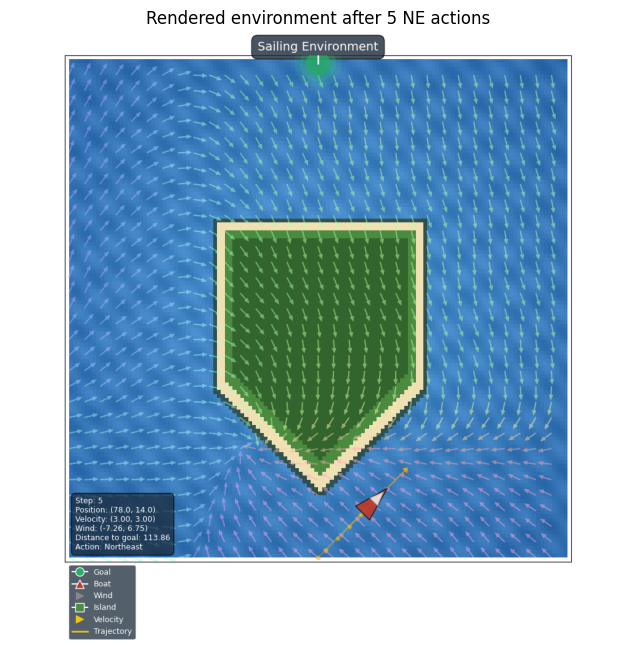

In [12]:

e = SailingEnv(
    **get_wind_scenario("training_1"),
    render_mode="rgb_array",
    show_full_trajectory=True,
)

obs, info = e.reset(seed=1)

for _ in range(5):
    obs, reward, terminated, truncated, info = e.step(1)  # North-East for demo

img = e.render()

print("Rendered image shape:", np.shape(img))
print("Rendered image dtype:", getattr(img, "dtype", type(img)))

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Rendered environment after 5 NE actions")
plt.show()


## 11. Fonctions utiles pour les prochains notebooks

In [13]:

def distance_to_goal(pos, goal=(64, 127)):
    pos = np.asarray(pos, dtype=float)
    goal = np.asarray(goal, dtype=float)
    return float(np.linalg.norm(pos - goal))


def distance_to_island(pos, world_map):
    # Approximate distance from a point to island cells. Useful for inspection/tuning only.
    pos = np.asarray(pos, dtype=float)

    ys, xs = np.where(world_map == 1)
    if len(xs) == 0:
        return np.inf

    d2 = (xs - pos[0])**2 + (ys - pos[1])**2
    return float(np.sqrt(d2.min()))


def is_in_island(pos, world_map):
    x = int(np.clip(round(float(pos[0])), 0, world_map.shape[1] - 1))
    y = int(np.clip(round(float(pos[1])), 0, world_map.shape[0] - 1))
    return bool(world_map[y, x] == 1)


p = np.array([64, 0])

print("distance_to_goal(start)   =", distance_to_goal(p, env.goal_position))
print("distance_to_island(start) =", distance_to_island(p, env.world_map))
print("is_in_island(start)       =", is_in_island(p, env.world_map))
print("is_in_island(center)      =", is_in_island(np.array([64, 60]), env.world_map))


distance_to_goal(start)   = 127.0
distance_to_island(start) = 17.0
is_in_island(start)       = False
is_in_island(center)      = True


## 12. Résumé à retenir

- L’environnement se crée avec `SailingEnv(**get_wind_scenario(name))`.
- La carte est dans `env.world_map`.
- Le champ de vent est dans `env.wind_field`.
- L’observation contient `position`, `velocity`, `local wind`, `full wind field`, `world map`.
- L’objectif est d’atteindre `(64, 127)` en moins de 500 steps.
- Toucher l’île met `is_stuck=True` et termine l’épisode.
- Les actions ne donnent pas directement un déplacement : la physique du vent modifie la vitesse.
